# ML Climate Zones Tutorial - Data Exploration
* Author: Stephen Haddad and Kate Brown.
* Affiliation: UK Met Office
* History: 1.0
* Last update: 2026-03-16
* © British Crown Copyright 2017-2026, Met Office. Please see LICENSE.md for license details.

### Running this notebook

This notebook has been tested on the scitools community ml environment. You can access this envrinment as follows:
* At the Met Office - load the relevant module `module load scitools/community/ml`
* Other platforms - Create a conda environment using the [yaml environment definition file](https://github.com/MetOffice/ssstack/blob/main/environments/ml-0.1.0.yml)

In [1]:
import pathlib
import os
import json

In [2]:
import matplotlib.pyplot
import cartopy.crs

In [3]:
import xarray
import pandas

In [4]:
CONFIG_PATH = pathlib.Path("../../config.json").resolve()

In [5]:
with open(CONFIG_PATH, "r") as tutorial_config_file:
    tutorial_config = json.load(tutorial_config_file)

In [6]:
def get_platform_dir(select_platform, config):
    try:
        root_path = pathlib.Path(config['default_dirs'][select_platform]) / 'climate_zones'
    except KeyError:
        root_path = pathlib.Path(os.environ['HOME']) / 'climate_zones'
    return root_path

In [7]:
current_platform = tutorial_config['platform']
root_data_dir = get_platform_dir(current_platform, tutorial_config)

ml_ready_dir = root_data_dir / 'ml_ready'

Only keeps the minimal metadata required for the representative workflow: one historic period, one future period, one future scenario, the 1.0 resolution, and the climate_zone / ML-ready file naming information:

In [8]:
resolutions_dict = {float(k1): v1 for k1, v1 in tutorial_config['resolutions_names'].items()}

dataset_prefix_dict = tutorial_config['dataset_prefix']

format_str = 'nc'
historic_scenario_str = 'historic'

In [9]:
fname_template = tutorial_config['fname_template']
time_dir_template = tutorial_config['time_dir_template']
ml_ready_fname_template =  tutorial_config['csv_out_template']

In [10]:
current_res = 1.0

In [11]:
select_historic = (1901, 1930)
select_future = (2071, 2099)
select_future_scenario = "ssp370"

Keeps the original notebook path-construction function, but only uses it to locate the selected representative files required for the reduced workflow.

???? seems to take accepts root_dir and suffix as arguments but then uses global variables root_data_dir and format_str instead - perculiar ? - mistake?

In [12]:
def get_data_path(root_dir, time_period, scenario_id, prefix, resolution_str, suffix) :
    start_year = time_period[0]
    end_year = time_period[1]
    if scenario_id == historic_scenario_str:
        data_dir = root_data_dir / time_dir_template.format(start_year=start_year,end_year=end_year)
    else:
        data_dir = root_data_dir / time_dir_template.format(start_year=start_year,end_year=end_year) / scenario_id 
    data_fname = fname_template.format(prefix=prefix, 
                                       res=resolution_str, 
                                       suffix=format_str)
    return data_dir / data_fname

Removes the full path catalogue and constructs only the files required for the representative workflow.

In [13]:
historic_climate_zone_path = get_data_path(root_dir=root_data_dir, time_period=select_historic, scenario_id=historic_scenario_str, prefix=dataset_prefix_dict["climate_zone"],
                                           resolution_str=resolutions_dict[current_res], suffix=format_str,)

future_climate_zone_path = get_data_path(root_dir=root_data_dir, time_period=select_future, scenario_id=select_future_scenario, prefix=dataset_prefix_dict["climate_zone"], 
                                         resolution_str=resolutions_dict[current_res], suffix=format_str,)

historic_climate_mean_path = get_data_path(root_dir=root_data_dir, time_period=select_historic, scenario_id=historic_scenario_str, prefix=dataset_prefix_dict["climate_mean"],
                                           resolution_str=resolutions_dict[current_res], suffix=format_str,)

Removes the broader dataset catalogue and loads only the datasets required for the representative workflows.

In [14]:
historic_climate_zone_ds = xarray.open_dataset(historic_climate_zone_path)
future_climate_zone_ds = xarray.open_dataset(future_climate_zone_path)
historic_climate_mean_ds = xarray.open_dataset(historic_climate_mean_path)

Removes historic and future visualisations into a single difference map to remove duplicate representations of the same workflow whilst still verifying climate_zone dataset opened
kg_class accessible, array comparison operation, xarray plotting, Cartopy rendering ect.

Text(0.5, 1.0, 'KG Climate Zones diff (2071, 2099) compared to (1901, 1930)')

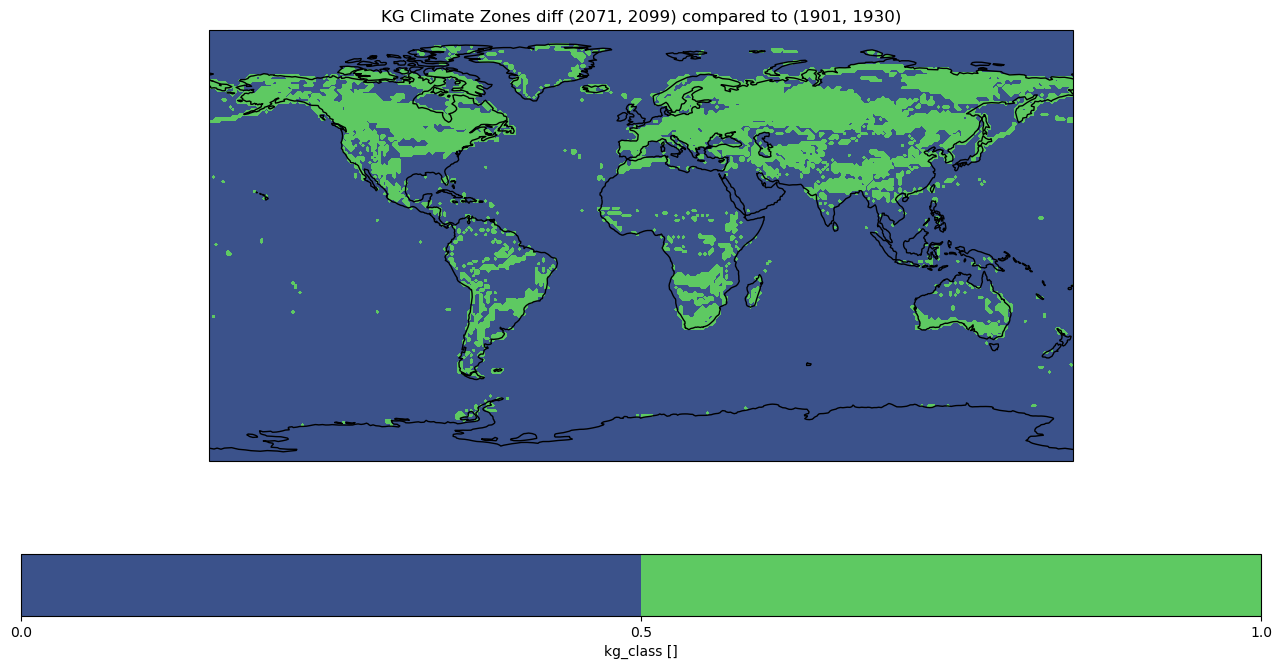

In [15]:
fig1 = matplotlib.pyplot.figure(figsize=(16, 8))

ax1 = fig1.add_subplot(1, 1, 1, projection=cartopy.crs.PlateCarree(),)
diff_arr = (future_climate_zone_ds["kg_class"]!=historic_climate_zone_ds["kg_class"])
diff_arr.plot.contourf(ax=ax1, transform=cartopy.crs.PlateCarree(), cbar_kwargs={"location": "bottom"},)

ax1.coastlines()
ax1.set_title(f"KG Climate Zones diff {select_future} compared to {select_historic}")

Replaces the monthly climatology figure with a single representative climate_mean workflow: select one month, select one variable, then visualise the result.

Text(0.5, 1.0, 'January Air Temperature')

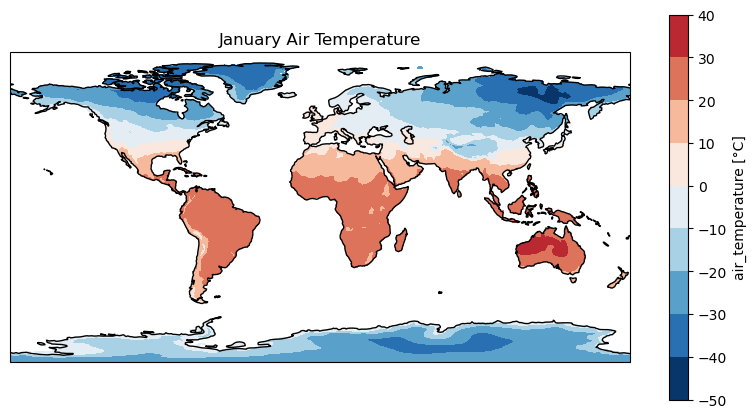

In [16]:
january_air_temperature = (historic_climate_mean_ds.loc[{"time": 1}]["air_temperature"])
fig1 = matplotlib.pyplot.figure(figsize=(10, 5))

ax1 = fig1.add_subplot(1, 1, 1,projection=cartopy.crs.PlateCarree(),)
january_air_temperature.plot.contourf(ax=ax1,transform=cartopy.crs.PlateCarree(),)

ax1.coastlines()
ax1.set_title("January Air Temperature")

Loads a representative subset of the ML-ready dataset (25,000 rows) to reduce runtime whilst preserving climate subgroup coverage for the retained workflow.

In [17]:
mlready_data_path = ml_ready_dir / ml_ready_fname_template.format(resolution=resolutions_dict[current_res])

In [18]:
zones_df = pandas.read_csv(mlready_data_path, nrows=25000)

<Axes: xlabel='climate_subgroup'>

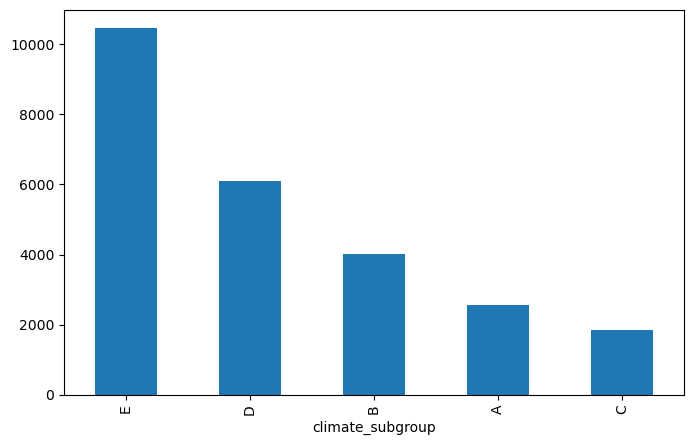

In [19]:
zones_df['climate_subgroup'].value_counts().plot.bar(figsize=(8,5))

Removed temperature histogram - climate subgroup aggregation and visualisation already exercises the ML-ready CSV workflow. Additional histogram views of the same dataset are removed as alternative representations of that workflow.

### Data statement
This data used in this notebook is derived from the Koppen-Geiger Climate Cliassfication dataset created by GloH2O.

###     References
- [Climate Zones Dataset](https://www.gloh2o.org/koppen/#:~:text=The%20K%C3%B6ppen%2DGeiger%20climate%20classification%20maps%20are%20high%2Dresolution,Climate%20Sensitivity%20(ECS)%2C%20and%20historical%20warming%20trend)